# **Deliverable 3: Ultrasound Physics & Imaging**

---

## Overview

This deliverable covers key concepts from **Lectures 19–24** (Weeks 8–9) of the course. You will explore the complete physics foundation underlying modern ultrasound imaging systems, from fundamental acoustic wave behavior through to clinical image formation and artifact management. Your work will integrate theoretical understanding with computational simulations and experimental design problems.

### Learning Outcomes:

Upon successful completion, you will be able to:
1. **Analyze** acoustic propagation through multi-layer tissue models to predict imaging penetration
2. **Design** ultrasound transducer systems with optimized beam characteristics for specific clinical applications
3. **Implement** ultrasound image reconstruction algorithms from simulated echo data
4. **Evaluate** Doppler measurement feasibility for given tissue depths and velocity ranges
5. **Identify and mitigate** artifacts in ultrasound images through understanding of physics mechanisms
6. **Compare and select** ultrasound imaging modes and parameters for clinical scenarios


---

# Part 1: Acoustic Physics & Tissue Interactions

## Key Concepts

**Impedance & Reflection:** Determines how much sound bounces at tissue boundaries
- Z = ρc (impedance in MRayl) — larger impedance mismatch → stronger reflection
- R = (Z₂ − Z₁)/(Z₂ + Z₁) (pressure reflection coefficient)
- R_I = R² (intensity reflection) — fraction of acoustic energy reflected
- T_I = 4Z₁Z₂/(Z₁+Z₂)² (intensity transmission) — fraction that passes through

**Attenuation:** Signal loss as sound travels through tissue due to absorption and scattering
- Loss = α · frequency · distance (higher frequency attenuates faster)
- α ≈ 0.5–0.8 dB/(cm·MHz) in soft tissue
- Round-trip loss: multiply distance by 2 (sound goes down and back up)
- Total loss in dB = 20·log₁₀(transmitted amplitude / received amplitude)

**Wavelength & Frequency:** Trade-off between resolution and penetration
- λ = c / f (c = 1540 m/s in soft tissue)
- Higher frequency f: shorter wavelength → better resolution but greater attenuation → shallower penetration
- Lower frequency f: longer wavelength → worse resolution but less attenuation → better penetration

## 1.1 Acoustic Impedance & Reflection Analysis

Acoustic impedance, Z = ρc, is the fundamental property determining how sound reflects at tissue boundaries. Ultrasound images are primarily formed from echoes at impedance boundaries.

### **Questions 1**
You are designing an ultrasound probe for cardiac imaging. The probe needs good acoustic coupling between the transducer (Z ≈ 25 MRayl) and skin (Z ≈ 1.54 MRayl). 
- a) Calculate the pressure reflection coefficient at the transducer-skin interface **without coupling gel**. What percentage of energy is lost to reflection (intensity)?
- b) Explain why coupling gel (Z ≈ 1.5 MRayl) improves transmission. Calculate the improvement in transmitted intensity.
- c) Why must matching layers be exactly λ/4 thick to optimally reduce reflections? (Hint: Consider wave interference.)

### **Questions 2**
In abdominal imaging, you encounter three successive tissue boundaries:
1. Skin (ρ = 1100 kg/m³, c = 1700 m/s) → Fat (ρ = 900 kg/m³, c = 1450 m/s)
2. Fat → Muscle (ρ = 1050 kg/m³, c = 1580 m/s)
3. Muscle → Bone cortical (ρ = 1850 kg/m³, c = 3500 m/s)

- a) Calculate Z for each tissue
- b) Calculate reflection coefficients at each boundary
- c) Rank the boundaries by reflection strength. Which is most problematic for imaging?
- d) Why are cortical bone landmarks often clearly visible as "dark shadows" in ultrasound?

### **Question 1 Answers**
- a)   The pressure reflection coefficient is about -0.884. The percentage of energy lost to reflection is ≈78.14%.
$$ R = \frac{Z_{2} - Z_{1}}{Z_{2} + Z_{1}} = \frac{1.54 - 25}{1.54 + 25} \approx -0.884 $$
$$ R_I = R^2 = (-0.884)^2 \approx 0.7814 \: \Rightarrow \: 78.14\% \text{ of the energy is reflected} $$

- b) Coupling improves transmission because it eliminates airgaps that would block all sound. 
$$ T_{transducer-gel} = \frac{4Z_{1}Z_{2}}{(Z_{1} + Z_{2})^2} = \frac{4 * 1.5 * 25}{(1.5 + 25)^2} \approx 0.214 \: \Rightarrow \: 21.4\% \: \text{intensity is transmitted}$$

$$ T_{transducer-air} = \frac{4 * 0.0004 * 25}{(0.0004 + 25)^2} \approx 0.000064 \: \Rightarrow \: 0.0064\% \: \text{intensity is transmitted}$$

- c) Matching layers are λ/4 thick so the reflected waves from the front and back of the layer are out of phase and cancel by destructive interference, minimizing reflection and maximizing transmitted energy.

Extra Sources:
- https://www.band-optics.com/blog/ar-vs-bbar-coatings.html


### **Question 2 Answers**
- a)  $$ Z = ρc $$
$$
Z_{skin} = 1100*1700 = 1.87 \text{ MRayl} \mid
Z_{fat} = 900*1450 = 1.305 \text{ MRayl} \mid
Z_{muscle} = 1050*1580 = 1.659 \text{ MRayl} \mid
Z_{bone} = 1850*3500 = 6.475 \text{ MRayl}
$$

- b & c) $$ R = \frac{Z_{2} - Z_{1}}{Z_{2} + Z_{1}} \mid R_I = R^2 $$
$$ R_{skin-fat} = \frac{1.305 - 1.87}{1.305 + 1.87} \approx -0.178 \mid R_{I: skin-fat} \approx 0.0317 \Rightarrow 3.17\%$$
$$ R_{fat-muscle} = \frac{1.659 - 1.305}{1.659 + 1.305} \approx 0.119 \mid R_{I: fat-muscle} \approx 0.0143 \Rightarrow 1.43\%$$
$$ R_{muscle-bone} = \frac{6.475 - 1.659}{6.475 - 1.659} \approx 0.592 \mid R_{I: muscle-bone} \approx 0.3506 \Rightarrow 35.06\%$$

- From strongest to weakest intensity:
    1. Muscle-bone: 35.06%
    2. Skin-fat: 3.17%
    3. Fat-muscle 1.43%


    The most problematic boundary is **muscle-to-bone** because the impedance mismatch is much larger than the other boundaries. 

- d) Bone causes dark acoustic shadows because its large impedance mismatch produces strong reflection. 

## 1.2 Multi-Layer Tissue Transmission Model

Ultrasound must penetrate through multiple tissue layers to reach target organs. Both reflection losses at each interface and attenuation within each tissue layer reduce the overall signal strength. This analysis predicts whether adequate signal will return for imaging.

### **Coding Exercise 1**

Implement a function to calculate total round-trip transmission through multiple tissue layers, accounting for:
1. **Interface losses:** Reflection loss at each boundary between different tissues
2. **Attenuation losses:** Frequency-dependent signal loss as sound propagates through each layer (round-trip)

Return the overall transmission loss in dB and identify the dominating loss mechanism(s).

In [5]:
import math
# TODO: Define tissue properties (impedance, attenuation coefficient, thickness)
# Create a list of dictionaries to store tissues and properties
tissues = [
    {
        "name": "Skin",
        "z": 1.87,
        "attenuation_coeff": 0.5,      
        "thickness_cm": 0.2
    },
    {
        "name": "Fat",
        "z": 1.305,
        "attenuation_coeff": 0.6,
        "thickness_cm": 2.0
    },
    {
        "name": "Muscle",
        "z": 1.659,
        "attenuation_coeff": 1.3,
        "thickness_cm": 3.0
    },
    {
        "name": "Bone",
        "z": 6.475,
        "attenuation_coeff": 5,
        "thickness_cm": 0.5
    }
]

# TODO: Calculate reflection losses at each interface
reflection_losses = []
for i in range(len(tissues) - 1):
    # Retrieve impedances
    z1 = tissues[i]["z"]
    z2 = tissues[i + 1]["z"]

    # Calculation Transmitted Intensity
    T_I = (4*z1*z2) / ((z1*z2)**2) 

    # Intensity loss in dB
    loss_db = 10 * math.log10(T_I**2)

    # Add dictionary of losses
    reflection_losses.append({
        "interface": f"{tissues[i]['name']} -> {tissues[i+1]['name']}",
        "loss_db": loss_db
    })
    
# TODO: Calculate attenuation losses through each layer (round-trip)
attenuation_losses = []
# assume 5mhz frequency
freq_mhz = 5
for t in tissues:
    # Round trip loss (times 2)
    loss_db = 2 * t["attenuation_coeff"] * freq_mhz * t["thickness_cm"]
    
    # add to a list of dictionaries
    attenuation_losses.append({
        "layer": t["name"],
        "loss_db": loss_db
    })

# TODO: Report total loss in dB and identify dominant mechanism
# Find total loss
total_reflection_loss = sum(r["loss_db"] for r in reflection_losses)
total_attenuation_loss = sum(a["loss_db"] for a in attenuation_losses)
total_loss = total_reflection_loss + total_attenuation_loss

# Find dominant contributor to loss
dominant_reflection = max(reflection_losses, key=lambda x: x["loss_db"])
dominant_attenuation = max(attenuation_losses, key=lambda x: x["loss_db"])

print("--- Summary ---")
print(f"Total reflection loss: {total_reflection_loss:.2f} dB")
print(f"Total attenuation loss: {total_attenuation_loss:.2f} dB")
print(f"Total loss: {total_loss:.2f} dB")
print("Dominant reflection loss:", dominant_reflection)
print("Dominant attenuation loss:", dominant_attenuation)


--- Summary ---
Total reflection loss: 1.04 dB
Total attenuation loss: 77.00 dB
Total loss: 78.04 dB
Dominant reflection loss: {'interface': 'Fat -> Muscle', 'loss_db': 5.332061872586039}
Dominant attenuation loss: {'layer': 'Muscle', 'loss_db': 39.0}


## 1.3 Clinical Penetration Analysis

### **Questions 3**

You are choosing the operating frequency for obstetric ultrasound in a pregnant patient at different gestational ages.
- a) **First Trimester (up to 3 cm depth through maternal tissue):** Compare 10 MHz vs. 5 MHz
  - Calculate expected round-trip loss through skin (0.2 cm) + adipose (2 cm) at both frequencies
  - Which frequency is better and why?

- b) **Third Trimester (6–8 cm depth):** Should you switch to a lower frequency? Estimate the penetration limit at 3.5 MHz (typical for this scenario).

### **Questions 4**

Abdominal imaging in an obese patient requires imaging through 5 cm of additional adipose tissue. Assuming a 2–5 MHz transducer:
- a) How much additional loss (in dB) occurs due to the extra fat layer?
- b) What compensatory adjustments to transducer power might be necessary?
- c) Why might harmonic imaging be attractive here despite resolution trade-offs?

### **Question 3 Answers**
- a) 
$$ \text{Round-trip loss}_{} = 2 * α * \text{frequency} * \text{distance} \mid \text{distance} = \text{skin} + \text{adipose} = 0.2 + 2 = 2.2cm  $$
$$ \text{Loss}_{10MHz} = 2 * 0.5 * 10 * 2.2 = 22dB $$
$$ \text{Loss}_{5MHz} = 2 * 0.5 * 5 * 2.2 = 11dB $$

Comparison:
- 10Mhz: 22dB loss offers better resolution
- 5MHz: 11dB loss offers better penetration

Since first trimester imaging is relatively shallow, 10Mhz should be better since not much penetration is needed. This is because higher frequency gives shorter wavelength and better spatial resolution.

- b) 
$$ \text{Loss}_{6cm} = 2 * 0.5 * 3.5 * 6 = 21dB $$
$$ \text{Loss}_{8cm} = 2 * 0.5 * 3.5 * 8 = 28dB $$

Yes, for the third-trimester you should switch to a lower frequency like 3.5MHz because of the larger distance which requires more penetration. At 6-8 cm the expected round-trip loss is around 21-28 dB.

### **Question 4 Answers**

- a) The additional 5 cm of fat can cause an extra 10dB round-trip loss at 2Mhz, 25dB at 5MHz.
$$ \text{Loss}_{2MHz} = 2 * 0.5 * 2 * 5 = 10dB $$
$$ \text{Loss}_{5MHz} = 2 * 0.5 * 5 * 5 = 25dB $$

- b) Because the extra fat causes more attenuation, the ultrasound signal becomes weaker. To compensate, the system may need to use more transmit power, more gain/TGC to improve penetration.

- c) Harmonic imaging may be useful here because it reduces near-field artifact, gives a narrower beam, and improves contrast, which can make structures easier to see in obese patients.

Extra Sources:
- https://www.ncbi.nlm.nih.gov/books/NBK570593/

---

# Part 2: Transducers & Beam Forming

## Key Concepts
**Wavelength & Element Spacing:** Fundamental limitation for phased arrays
- λ = c / f (c = 1540 m/s)
- Element spacing s ≤ λ/2 — prevents unwanted secondary lobes (grating lobes)

**Beam Geometry:** How the acoustic beam spreads and focuses
- Near-field length: N = D²/(4λ) where D = aperture diameter — distance from transducer to focal point
- Far-field divergence angle: θ ≈ λ/D (radians) — beam spreads beyond focal point
- Lateral resolution at focal depth: ≈ λ·z/D (z = focal depth) — tightest beam at focal point

**Axial Resolution:** Along the beam direction, determined by pulse length
- δz = (c · τ) / 2 where τ = pulse duration — shorter pulses give better resolution
- Trade-off: shorter pulses require wider bandwidth, which reduces signal-to-noise ratio

**Focal Zone:** Where beam is narrowest and lateral resolution is best
- Lateral resolution is excellent at focal depth, degrades in near field and far field
- Multiple focal zones (electronic or mechanical) improve coverage but reduce frame rate

## 2.1 Transducer Design & Near-Field Analysis

### **Questions 5**

You are designing a linear array transducer for abdominal imaging. Frequency: 5 MHz, Desired penetration: 15 cm, Focal zone: ~4 cm
- a) Calculate the wavelength in soft tissue at 5 MHz (c = 1540 m/s)
- b) What is the minimum element spacing to avoid grating lobes (phased array constraint)?
- c) To achieve 4 cm focal zone, what aperture diameter (number of active elements) is required? (Hint: N = D²/(4λ))
- d) Compare a 64-element vs 128-element array: which has better lateral resolution and why?

### **Questions 6**

A 7.5 MHz transducer for cardiac imaging through intercostal spaces has a diameter of 12 mm.
- a) Calculate the near-field length
- b) Calculate the far-field divergence angle
- c) Can this transducer achieve useful resolution at 10 cm depth (typical mitral valve location)? Why or why not?

### **Question 5 Answers**
- a) The wavelength is 3.08 * 10^-4 m or 0.308 mm
$$λ = \frac{c}{f} = \frac{1540}{5 * 10^6} = 3.08 * 10^{-4} \text{ m} \Rightarrow 0.308 \text{ mm}$$

- b) The minimum element spacing to avoid grating lobes is 0.154 mm
$$ s \leq \frac{λ}{2} \mid s_{max} = \frac{λ}{2} = \frac{0.308\text{ mm}}{2} = 0.154 \text{ mm} $$

- c) To achieve a focal zone of 4 cm, the aperature diameter must be about 7.02 mm 
$$ N = \frac{D^2}{4λ} \Rightarrow D = \sqrt{4λN} = \sqrt{4 * 3.08 * 10^{-4} * 0.04} \approx 0.00702 \text{ m or } 7.02 \text{ mm} $$

- d) The 128-element array has better lateral resolution because it provides a larger effective aperture, which produces a narrower beam and tighter focusing at the focal depth.

Extra Sources
- https://pmc.ncbi.nlm.nih.gov/articles/PMC12467595/

### **Question 6 Answers**
- a)
$$ λ = \frac{c}{f} = \frac{1540}{7.5 * 10^6} \approx 2.053 * 10^{-4} \text{ m or } 0.2053 \text { mm}$$
$$ N = \frac{D^2}{4λ} = \frac{12 \text{ mm}}{4 * 0.2053 \text{ mm}} \approx 175.3 \text{ mm or } 17.53 \text{ cm} $$

- b) 
$$ θ \approx \frac{λ}{D} \approx \frac{0.2053}{12} \approx 0.0171 \text{ rad} $$

- c) Yes, this transducer can achieve a useful resolution at 10 cm depth since that depth is still within the near field length. (10 cm < 17.53 cm)


## 2.2 Electronic Beam Steering & Focusing

### **Coding Exercise 2**

Implement a phased array beam-forming simulator. Calculate the time delays required to:
1. **Focus the transmit beam** at a specified focal depth
2. **Steer the beam** to a specified angle
3. **Simulate receive beam forming** by applying delays to received signals

Visualize the resulting beam pattern and assess the impact of different arrays (64 vs 128 elements) and frequencies.

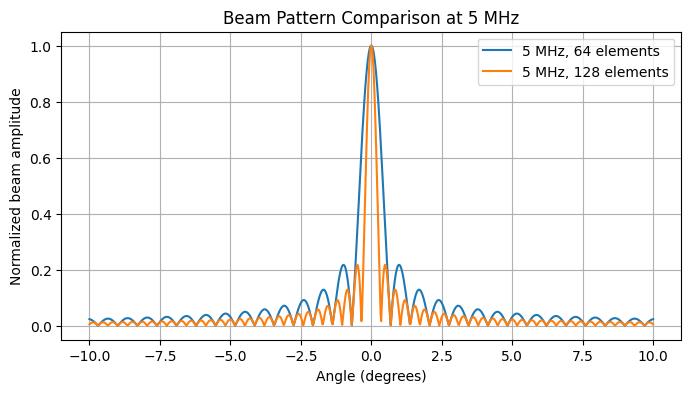

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Calculate wavelength and set up array geometry
# Calculate wavelength
def calculate_wavelength(frequency):
    return 1540 / frequency

# set up array with number of elements and spacing
# Center the array at x = 0
def get_element_positions(num_elements, spacing):
    return (np.arange(num_elements) - (num_elements - 1) / 2) * spacing

# TODO: Calculate transmit delays for focusing at specified depth
def focus_delays(x_positions, focus_depth, c):
    # Distance from each element to the focal point
    distances = np.sqrt(x_positions**2 + focus_depth**2)
    
    # Convert path difference into delay
    return (distances - np.min(distances)) / c

# TODO: Calculate transmit delays for beam steering at specified angle
# Linear delay pattern for steering
def steer_delays(x_positions, steer_angle, c):
    return (x_positions * np.sin(steer_angle)) / c

# TODO: Simulate and visualize beam patterns
def visualize_beam_pattern(num_elements, spacing, wavelength, label):
    # Calculate element positions
    x_positions = get_element_positions(num_elements, spacing)

    # Angle range for beam pattern
    angles_deg = np.linspace(-10, 10, 1000)
    angles_rad = np.radians(angles_deg)

    pattern = []

    for angle in angles_rad:
        # Simple array factor
        phase = 2 * np.pi * x_positions * np.sin(angle) / wavelength
        signal = np.sum(np.exp(1j * phase))
        pattern.append(np.abs(signal))

    pattern = np.array(pattern)
    pattern = pattern / np.max(pattern)

    # Plot beam pattern
    plt.plot(angles_deg, pattern, label=label)

# TODO: Compare different array configurations (64 vs 128 elements)
# Element spacing, covert to meters for calculations
element_spacing_mm = 0.4
element_spacing = element_spacing_mm / 1000  

# Focus depth in cm, covert to m for calculations
focus_depth_cm = 4
focus_depth = focus_depth_cm / 100            # convert to meters

# Steer angle at 15 degrees, convert to radians for calculkations
steer_angle_deg = 15
steer_angle = np.radians(steer_angle_deg)

# Use one frequency only
frequency_mhz = 5
frequency_hz = frequency_mhz * (10**6)
wavelength = calculate_wavelength(frequency_hz)

# TODO: Calculate wavelength and element positions# TODO: Calculate transmit delays for focusing and steering# ...

# Compare 64 vs 128 elements
plt.figure(figsize=(8, 4))

visualize_beam_pattern(64, element_spacing, wavelength, "5 MHz, 64 elements")
visualize_beam_pattern(128, element_spacing, wavelength, "5 MHz, 128 elements")

plt.xlabel("Angle (degrees)")
plt.ylabel("Normalized beam amplitude")
plt.title("Beam Pattern Comparison at 5 MHz")
plt.legend()
plt.grid(True)
plt.show()



The plot shows the main lobe centered at 0° and side lobes on either side. 
The 128-element array produces a narrower main lobe than the 64-element array, indicating better lateral resolution. 

This dshows that increasing the number of array elements improves beam focusing and beam sharpness.

## 2.3 Lateral Resolution Across Focal Zone

### **Questions 7**

A 5 MHz linear array with 128 elements and 0.4 mm spacing is used for abdominal imaging with an electronic focal depth of 6 cm.
- a) Calculate the lateral resolution at the focal depth
- b) Calculate the lateral resolution at 1 cm (near field) and 15 cm (far field)
- c) Plot lateral resolution vs depth. At what depths does lateral resolution exceed (degrade beyond) 1 mm?
- d) How could you improve lateral resolution at 15 cm depth? What are the trade-offs of each approach?

### **Question 7 Answers**

- a)
$$ λ = 0.308 \text{ mm} \mid D \approx \text{spacing} * \text{number of elements} \approx 0.4 \text { mm} * 128 \approx 51.2 \text{ mm} \mid 6 \text{ cm} = 60 \text { mm}$$
$$ \text{Lateral Resolution} \approx \frac{λ * z}{D} \approx \frac{0.308 * 60}{51.2} \approx 0.361 \text{ mm}$$

- b) 
$$ \text{Lateral Resolution at 1cm} \approx \frac{0.308 * 10}{51.2} \approx 0.0602 \text{ mm}$$
$$ \text{Lateral Resolution at 15cm} \approx \frac{0.308 * 150}{51.2} \approx 0.902 \text{ mm}$$

- c)



Lateral resolution exceeds 1 mm beyond about 16.62 cm


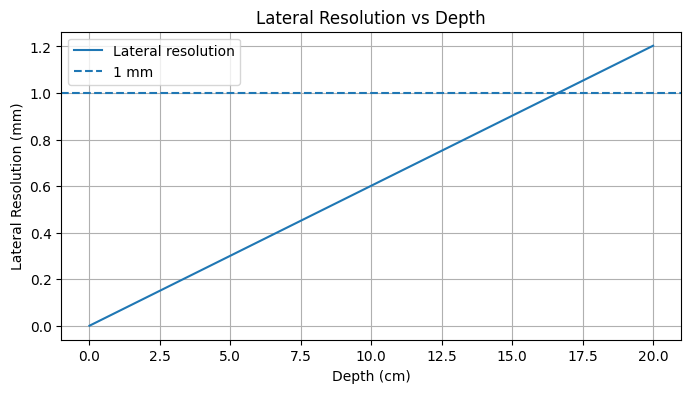

In [15]:
import numpy as np
import matplotlib.pyplot as plt

wavelength_mm = 0.308
D_mm = 51.2

# Depths from 0 to 10 cm
depths_cm = np.linspace(0, 20, 1000)
depths_mm = depths_cm * 10

# Calculate lateral resolution
lateral_resolution_mm = (wavelength_mm * depths_mm) / D_mm

# calculate limit
depth_limit_cm = (D_mm / wavelength_mm) / 10
print(f"Lateral resolution exceeds 1 mm beyond about {depth_limit_cm:.2f} cm")

# plot depth vs lateral resolution
# also add horizontal line for 1mm cut off
plt.figure(figsize=(8, 4))
plt.plot(depths_cm, lateral_resolution_mm, label="Lateral resolution")
plt.axhline(1.0, linestyle="--", label="1 mm")          
plt.xlabel("Depth (cm)")
plt.ylabel("Lateral Resolution (mm)")
plt.title("Lateral Resolution vs Depth")
plt.grid(True)
plt.legend()
plt.show()



- d) Lateral resolution at 15 cm can be improved by narrowing the beam using stronger focusing, higher scan line density, or multiple focal depths. However, stronger focusing increases beam divergence beyond the focus, and multiple focal zones reduce temporal resolution by lowering frame rate.

Extra Sources:
- https://radiopaedia.org/articles/lateral-resolution-ultrasound

# Part 3: Image Formation & Reconstruction

---

## Key Concepts

**Time-Distance Relationship:** Converting echo timing to depth
- Depth = (c × time) / 2 where time is round-trip, c = 1540 m/s
- Every echo is displayed as a scan line, with brightness (intensity) encoded from the echo amplitude
- Axial resolution limited by pulse duration: δz = (c · τ) / 2 — can't resolve echoes closer than one pulse length apart

**Signal Processing Pipeline:** Sequential steps to convert raw RF data to viewable B-mode image
1. **Envelope Detection:** Extract amplitude envelope from RF signal — removes high-frequency carrier, keeps time-varying amplitude
2. **TGC (Time-Gain Compensation):** Multiply by gain increasing with depth to correct for attenuation losses
3. **Log Compression:** Convert to dB scale — compresses ~100 dB dynamic range to ~50 dB for display
4. **Scan Conversion:** Map from polar (angle, depth) to Cartesian (x, y) coordinates for rectangular display

**Frame Rate Constraint:** Speed at which images update on screen
- Time per scanline ≈ 2·(max depth)/c — limited by sound travel time
- Frame rate = 1 / (time per scan_line × num_scanlines)
- Adding multiple focal zones increases scanline time → reduces frame rate (trade-off for better image quality)

## 3.1 B-Mode Image Formation from Echo Data

### **Questions 8**
In a B-mode ultrasound image, three echoes are detected at times 50 μs, 80 μs, and 150 μs, with amplitudes 60 dB, 40 dB, and 25 dB respectively.
- a) Calculate the depths of the three reflectors (c = 1540 m/s)
- b) If the transducer is operating at 5 MHz with a 2-cycle pulse length, what is the axial resolution?
- c) Can the system resolve the first two echoes, or will they merge? Justify.
- d) Explain why all three echoes must be displayed on a logarithmic (dB) scale rather than linear amplitude.

### **Questions 9**
A linear array acquires 128 scan lines at 50 frames/second. Each scan line goes to 15 cm depth. 
- a) Calculate the time available per scan line for transmit + receive
- b) Is this sufficient for sound to travel to 15 cm and return? (Include time for multiple focal zones.)
- c) If the system uses 2 focal zones instead of 1, how is frame rate affected?
- d) What happens to temporal resolution (ability to detect motion) if you add a second focal zone?

### **Question 8 Answers** 
- a) $$ \text{Depth} = \frac{ct}{2}$$
$$ \text{Depth at 50μs} = \frac{1540 * 50 * 10^{-6}}{2} = 0.0385 \text{ m} = 3.85 \text{ cm}$$
$$ \text{Depth at 80μs} = \frac{1540 * 80 * 10^{-6}}{2} = 0.0616 \text{ m} = 6.16 \text{ cm}$$
$$ \text{Depth at 150μs} = \frac{1540 * 150 * 10^{-6}}{2} = 0.1155 \text{ m} = 11.55 \text{ cm}$$

- b) $$SPL = nλ = 2 * 0.308 \text{ mm} = 0.616 \text{ mm}\mid Δa = \frac{SPL}{2} = \frac{0.616 \text{ mm}}{2} = 0.308 \text{ mm}$$

- c) 6.16 - 3.85 = 2.31 cm = 23.1 mm. Yes the first two echoes will be resolved because their separation (23.1mm) is much greater than the spatial pulse length of 0.616 mm.

- d) Since amplitudes span 25-60dB range and display can only show ~30dB, log compression is used to make strong and weak signals visible within the same image.

### **Question 9 Answers** 
- a) 
$$ \text{Frame Rate} = \frac{1}{\text{time per scan line} * \text{\# of scan lines}} $$
$$ \text{time per scan line} = \frac{1}{\text{frame rate} * \text{\# of scan line}} = \frac{1}{50 * 128} = 156.25 \text{ μs}$$

- b) No, each scan line requires about 194.8 μs per scan line to reach 15 cm and back.
$$ \text{Time per scanline} \approx \frac{2 * \text{max depth}}{c} \approx \frac{2 * 0.15}{1540} \approx 194.8 \text{ μs}$$

- c) Using 2 focal zones increases the scan line time, meaning it will reduce the frame rate.

- d) Since increasing the number of focal zones reduce frame rate, it will also worsen the temporal resolution and motion will be detected less accurately.

## 3.2 Ultrasound Image Reconstruction from Simulated Echo Data

### **Coding Exercise 3**

Implement a B-mode image reconstruction pipeline from simulated RF echo data:

1. **Create synthetic scattering phantom** using point scatterers
2. **Compute echo signals** for each beam direction
3. **Generate RF data** at transducer frequency
4. **Signal Processing:**
   - Envelope detection (analytic signal)
   - Time-gain compensation (TGC)
   - Log compression (dB scaling)
5. **Scan Conversion:** Map polar to Cartesian coordinates
6. **Display and analyze** reconstructed B-mode image

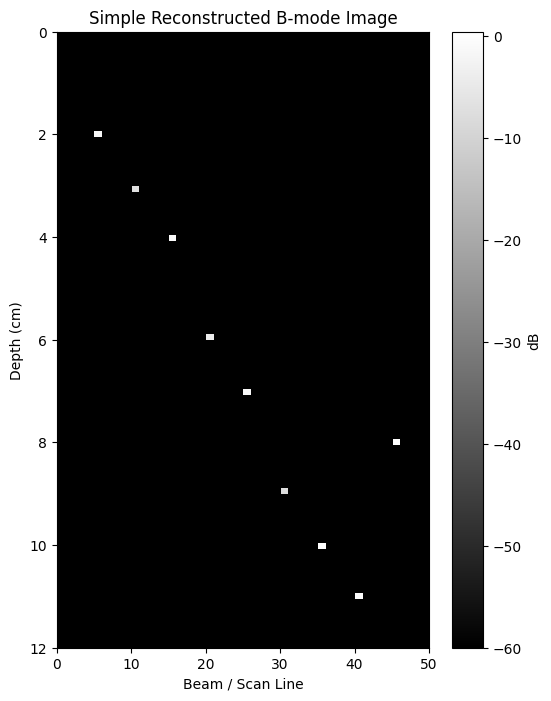

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Create synthetic scattering phantom using point scatterers
# (scan line index, depth in meters, amplitude)
scatterers = [
    (5,  0.02, 0.9),
    (10, 0.03, 1.0),
    (15, 0.04, 0.7),
    (20, 0.06, 0.8),
    (25, 0.07, 0.6),
    (30, 0.09, 0.6),
    (35, 0.10, 0.9),
    (40, 0.11, 0.5),
    (45, 0.08, 0.7)
]

# TODO: Simulate RF echo data for each scanline
# Extra setup paramters
num_beams = 50
num_depths = 100
max_depth = 0.12

# depth samples from 0 to max depth
depths = np.linspace(0, max_depth, num_depths)    

# place each scatterer into nearest depth sample on its beam
echo_data = np.zeros((num_depths , num_beams))
for line, depth_m, amplitude in scatterers:
    depth_index = np.argmin(np.abs(depths - depth_m))
    echo_data[depth_index, line] = amplitude

# sinusoidal carrier to imitate RF ultrasound data
carrier = np.sin(np.linspace(0, 20 * np.pi, num_depths))

# multiply echo amplitutes by the carrier
rf_data = np.zeros((num_depths, num_beams))
for beam in range(num_beams):
    rf_data[:, beam] = echo_data[:, beam] * carrier


# TODO: Apply envelope detection to extract amplitude from RF signal
envelope = np.abs(rf_data)

# TODO: Apply time-gain compensation (TGC)
# multiply by gain increasing with depth to correct for attenuation losses
tgc = np.linspace(1, 2, num_depths)
envelope_tgc = envelope * tgc[:, np.newaxis]

# TODO: Apply log compression (dB scale)
# Convert to logarithmic scale for display
bmode = 10 * np.log10(envelope_tgc + 1e-6)

# TODO: Perform scan conversion (polar to Cartesian)
# TODO: Display and analyze reconstructed B-mode image
plt.figure(figsize=(6, 8))
plt.imshow(
    bmode,                      # treat beam lines like image columns
    cmap="gray",
    aspect="auto",
    extent=[0, num_beams, max_depth * 100, 0]
)
plt.xlabel("Beam / Scan Line")
plt.ylabel("Depth (cm)")
plt.title("Simple Reconstructed B-mode Image")
plt.colorbar(label="dB")
plt.show()

## 3.3 Shepp-Logan Phantom Reconstruction

### **Coding Exercise 4**

Validate your B-mode reconstruction pipeline from **Coding Exercise 3** by applying it to a **Shepp-Logan digital phantom**. This simulates a more realistic imaging scenario with defined tissue-like features, allowing you to assess how well your algorithm handles anatomically-plausible structures compared to the simple synthetic scatterers in Exercise 3.

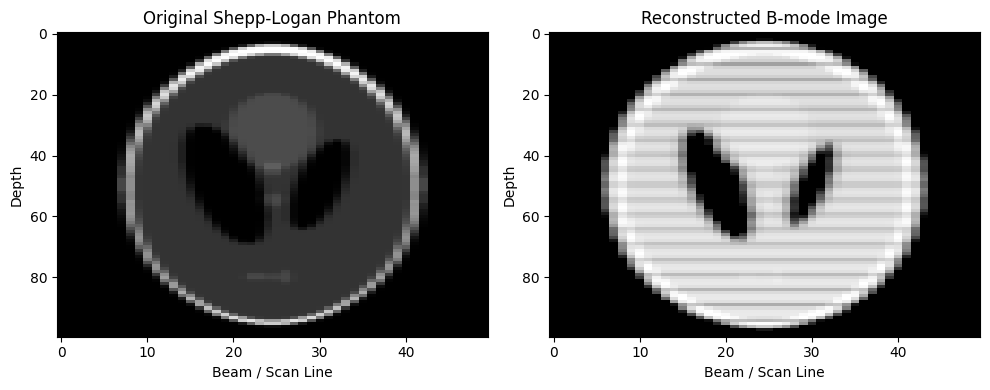

In [28]:
# TODO: Load Shepp-Logan phantom
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt

# load phantom
phantom = shepp_logan_phantom()

# Resize phantom to match a simple beam-depth image size
num_depths = 100
num_beams = 50
phantom = resize(phantom, (num_depths, num_beams), anti_aliasing=True)

# TODO: Apply your reconstruction pipeline from Exercise 3 to this phantom
# ...
# Use the phantom directly as echo data
echo_data = phantom

# sinusoidal carrier to imitate RF ultrasound data
carrier = np.sin(np.linspace(0, 20 * np.pi, num_depths))

# multiply echo amplitutes by the carrier
rf_data = np.zeros((num_depths, num_beams))
for beam in range(num_beams):
    rf_data[:, beam] = echo_data[:, beam] * carrier

# TODO: Apply envelope detection to extract amplitude from RF signal
envelope = np.abs(rf_data)

# TODO: Apply time-gain compensation (TGC)
# multiply by gain increasing with depth to correct for attenuation losses
tgc = np.linspace(1, 2, num_depths)
envelope_tgc = envelope * tgc[:, np.newaxis]

# TODO: Apply log compression (dB scale)
# Convert to logarithmic scale for display
bmode = 10 * np.log10(envelope_tgc + 1e-6)

# TODO: Compare reconstructed image quality with ground truth
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(phantom, cmap="gray", aspect="auto")
plt.title("Original Shepp-Logan Phantom")
plt.xlabel("Beam / Scan Line")
plt.ylabel("Depth")

plt.subplot(1, 2, 2)
plt.imshow(bmode, cmap="gray", aspect="auto", vmin=-50, vmax=0)
plt.title("Reconstructed B-mode Image")
plt.xlabel("Beam / Scan Line")
plt.ylabel("Depth")

plt.tight_layout()
plt.show()

### **Analysis**

Compare reconstructed image with the ground truth phantom. Assess image quality and artifacts introduced by the ultrasound imaging process

Compared with the original Shepp-Logan phantom, the reconstructed B-mode image preserves the main shape and internal structures, but shows some horizontal banding due to the simplified RF simulation. The overall geometry is still visible, so the reconstruction pipeline captures the main features of the phantom.

## 3.4 Signal Processing & Dynamic Range

### **Questions 10**
Received RF echo signal ranges from -50 mV to +50 mV. After envelope detection and TGC, dynamic range is 0.1–100 mV (1000:1 or ~60 dB).
- a) Why does linear display (0–100 scale) make weak signals invisible?
- b) Apply log compression. What is the resulting dB range?
- c) With 8-bit display (0–255 levels), how many dB per level? Sufficient for 3 dB myocardial contrast differences?
- d) How does 16-bit display depth improve visualization of subtle tissue differences?

### **Question 10 Answers**

- a) Because the signal range is very large. A 100mV signal is 1000 times larger than a 0.1mV signal, so on a linear scale the strong echoes take up most of the display range while the weak echoes are squeezed to almost zero. Weak signals look dark as a result.

- b) The range is 0dB to 60dB 
$$ 20\log(\frac{100}{0.1}) = 60 dB$$

- c) Yes, an 8-bit display is sufficient for 3dB contrast differences since the dB/level is small enough. 
$$ \frac{60}{256} \approx 0.234 \text{ dB per level} $$

- d) A 16-bit display has 2^16 or 65536 different levels that can represent the dB range, smaller signal differences can be displayed as visible changes. This makes subtle tissue differences easier to see.

# Part 4: Doppler Imaging & Artifact Analysis

---

## Key Concepts

**Doppler Shift:** Frequency change from moving targets (blood flow)
- Δf = 2f₀·v·cos(θ)/c — factor of 2 because sound travels to target and returns
- Only velocity component along beam (cos(θ)) contributes; perpendicular motion is invisible
- v_max = c·PRF / (4f₀·cos(θ)) [Nyquist limit for pulsed Doppler] — velocities above this exceed sampling rate
- Below Nyquist: velocity measured correctly; above Nyquist: aliasing occurs (velocity appears reversed)

**Artifacts:** Misinterpretation of ultrasound signal caused by physics assumptions
- **Shadowing:** Strong attenuator (bone, gas) blocks transmission → dark (anechoic) region directly behind
- **Enhancement:** Low-attenuation region (fluid-filled cyst) allows more signal → bright region directly behind  
- **Mirror Image:** Reflection off strong smooth surface (diaphragm, bone) creates false duplicate structure on opposite side
- **Reverberation:** Multiple bounces between two strong reflectors → equally-spaced ghost echoes
- **Speckle:** Inherent grainy texture from constructive/destructive interference of scattered signals — characteristic ultrasound appearance

## 4.1 Pulsed-Doppler Velocity Measurement

### **Questions 11**

A 5 MHz pulsed-Doppler system measures blood flow in the carotid artery.
- a) A red blood cell moving at 0.8 m/s toward the transducer causes a Doppler shift. Calculate shift frequency (assume 60° angle, c = 1540 m/s)
- b) System has PRF = 6 kHz. Calculate the Nyquist velocity limit.
- c) Can you measure 0.8 m/s without aliasing?
- d) What PRF is needed to measure 1.5 m/s at 60° angle without aliasing?

### **Questions 12**
In severe carotid stenosis, peak systolic velocity reaches 4 m/s.
- a) Can standard PW Doppler (PRF ~ 8 kHz, f = 5 MHz, θ = 60°) measure this without aliasing?
- b) What is the maximum velocity this system can measure?
- c) How would you modify the system for higher velocities? What are the trade-offs?

### **Question 11 Answers**

- a) $$ Δf = \frac{2f_{0}v\cos(θ)}{c} = \frac{2(5 * 10^6)(0.8)\cos(60)}{1540} \approx 2597 \text{ Hz} $$

- b) $$ v_{max} = \frac{c * \text{PRF}}{4f_{0}\cos(θ)} = \frac{1540 * 6000}{4(5*10^6)\cos(60)} = 0.924 \text{ m/s}$$ 
 
- c) Yes since the cell speed is less than the nyquist limit (0.8 < 0.924), we can measure without aliasing.

- d) $$ \text{PRF} = \frac{4v_{max}f_{0}\cos(0)}{c} = \frac{4(1.5)(5*10^6)\cos(60)}{1540} \approx 9740 \text{ Hz or } 9.74 \text{ KHz}$$

### **Question 12 Answers**

- a) No, a standard PW Doppler system cannot measure 4 m/s since it is greater than the nyquist limit. (4 > 1.232)
$$ v_{max} = \frac{1540 * 8000}{4(5*10^6)\cos(60)} = 1.232 \text{ m/s} $$

- b) The maximum velocity the PW Doppler system can capture is 1.232 m/s.

- c) In order to measure higher velocities, you can...
    - Increase PRF, but it will decrease the maximum depth that can be measured
    - Decrease frequency, but will also lower the resolution

Extra Sources:
- https://pie.med.utoronto.ca/TEE/TEE_content/TEE_spectral_intro.html

## 4.2 Artifact Identification & Mitigation

### **Coding Exercise 5**

**PART A:**
Load your reconstructed B-mode image from **Coding Exercise 3 or 4** and analyze what artifacts you actually see:

1. **Identify present artifacts:** Examine speckle patterns, reconstruction artifacts (ringing, aliasing), any other visual anomalies
2. **Characterize severity:** Describe the magnitude, spatial distribution, and impact on image quality
3. **Quantify where possible:** Calculate speckle statistics, measure artifact extent, assess signal-to-noise
4. **Visual documentation:** Display the image and annotate observed artifacts

**PART B:** Choose **one** artifact type that was NOT naturally present in your reconstructed image.

1. **Inject the artifact** synthetically onto your reconstructed imageFor your chosen artifact, create:
2. **Implement a detector** for that artifact type
3. **Test sensitivity:** Vary artifact parameters and measure detection performance5. **Assess trade-offs:** Show what detail is preserved vs. what is lost
4. **Implement mitigation** to reduce the artifact

Observed artifacts: banding-like texture
Mean intensity: -33.23470313204316
Standard deviation: 25.46599054759049
Speckle statistic (mean/std): -1.3050622582276785


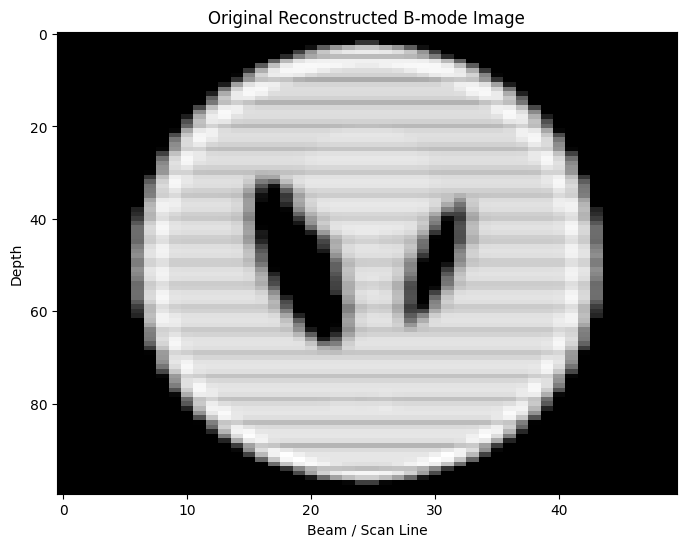

Detected shadow mean intensity: -37.7050401737886


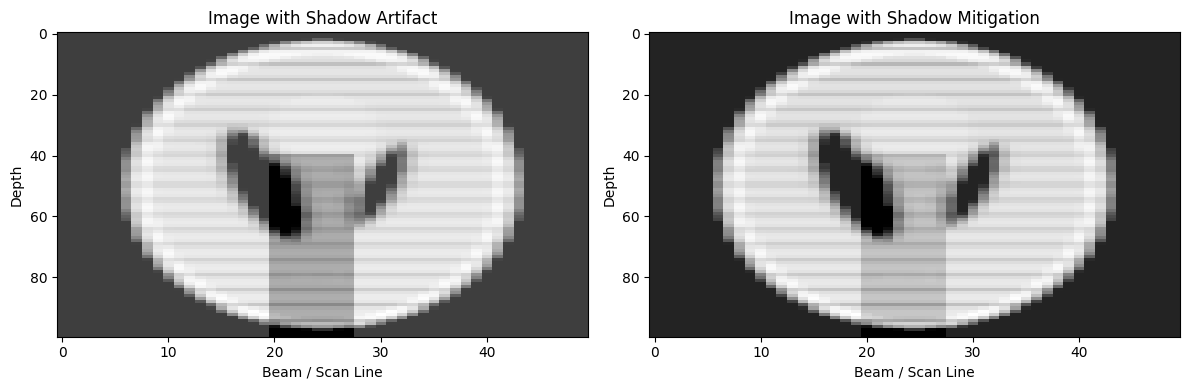

In [41]:
# PART A: Analyze Natural Artifacts
# TODO: Load your reconstructed B-mode image from Exercise 3 or 4

from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt

# load phantom
phantom = shepp_logan_phantom()

# Resize phantom to match a simple beam-depth image size
num_depths = 100
num_beams = 50
phantom = resize(phantom, (num_depths, num_beams), anti_aliasing=True)

# Apply your reconstruction pipeline from Exercise 3 to this phantom

# Use the phantom directly as echo data
echo_data = phantom

# sinusoidal carrier to imitate RF ultrasound data
carrier = np.sin(np.linspace(0, 20 * np.pi, num_depths))

# multiply echo amplitutes by the carrier
rf_data = np.zeros((num_depths, num_beams))
for beam in range(num_beams):
    rf_data[:, beam] = echo_data[:, beam] * carrier

# Apply envelope detection to extract amplitude from RF signal
envelope = np.abs(rf_data)

# Apply time-gain compensation (TGC)
# multiply by gain increasing with depth to correct for attenuation losses
tgc = np.linspace(1, 2, num_depths)
envelope_tgc = envelope * tgc[:, np.newaxis]

# Apply log compression (dB scale)
# Convert to logarithmic scale for display
bmode = 10 * np.log10(envelope_tgc + 1e-6)

# TODO: Identify and characterize artifacts present in your image
print("Observed artifacts: banding-like texture")

# TODO: Quantify artifact properties (speckle statistics, artifact extent, etc.)
mean_intensity = np.mean(bmode)
std_intensity = np.std(bmode)
speckle_stat = mean_intensity / std_intensity

print("Mean intensity:", mean_intensity)
print("Standard deviation:", std_intensity)
print("Speckle statistic (mean/std):", speckle_stat)

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(bmode, cmap="gray", aspect="auto")
plt.title("Original Reconstructed B-mode Image")
plt.xlabel("Beam / Scan Line")
plt.ylabel("Depth")
plt.show()

# PART B: Inject Your Choice of Artifact
# TODO: Choose one artifact type (shadowing, enhancement, reverberation, or other)
# Shadowing artifact
shadow_artifact = bmode.copy()

# TODO: Synthetically inject the artifact onto your reconstructed image
shadow_col_start = 20
shadow_col_end = 28
shadow_row_start = 40
shadow_artifact[shadow_row_start:, shadow_col_start:shadow_col_end] -= 20

# TODO: Implement a detector for your chosen artifact
shadow_region = shadow_artifact[shadow_row_start:, shadow_col_start:shadow_col_end]
shadow_mean = np.mean(shadow_region)

print("Detected shadow mean intensity:", shadow_mean)

# TODO: Test detector performance and implement mitigation
# brighten the shadowed region slightly
shadow_mitigated = shadow_artifact.copy()
shadow_mitigated[shadow_row_start:, shadow_col_start:shadow_col_end] += 10

# Show injected artifact and mitigated image
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(shadow_artifact, cmap="gray", aspect="auto")
plt.title("Image with Shadow Artifact")
plt.xlabel("Beam / Scan Line")
plt.ylabel("Depth")

plt.subplot(1, 2, 2)
plt.imshow(shadow_mitigated, cmap="gray", aspect="auto")
plt.title("Image with Shadow Mitigation")
plt.xlabel("Beam / Scan Line")
plt.ylabel("Depth")

plt.tight_layout()
plt.show()

## 4.3 Clinical Artifact Case Studies

### **Questions 13**

You observe a dark (anechoic) structure within the gallbladder at 5 cm depth with a bright acoustic shadow extending below it.
- a) Is this definitely a gallstone? Explain the physical basis of the shadow.
- b) Could it be a polyp instead? What would distinguish them on ultrasound?

### **Questions 14**

You observe a round, dark (anechoic) mass at 8 cm depth with a bright region immediately behind it.
- a) Is this definitely a cyst? Could it be a hypoechoic solid tumor instead?
- b) Explain the physics of acoustic enhancement behind fluid-filled structures.

### **Question 13 Answers**
- a) No, it is not 100% certain that it is a gallstone but is likely. The shadow occurs due to acoustic shadowing, when the object is a strong reflector and attenuates the ultrasound beam so little sound passes through it.
- b) Yes, the object may also be a polyp. If there is shadowing behind echogenic focus, then it confirms that it is a gallstone, otherwise it may be a polyp instead.

### **Question 14 Answers**
- a) No, it is not 100% cetain that it is a cyst, but is likely. It is less likely to be a hyperechoic tumor because it usually appears gray compared to surrounding tissue and produces echoes.
- b) Acoustic enhancement occurs when sound passes through low-attenuation structures like fluid, which makes sound pass through and produces more echoes. This makes the region behind fluid-filled structures to appear brighter.


---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable3.ipynb` and `.pdf`

**Due:** Monday, March 16, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Acoustic Physics & Tissue Interactions** | Q1 (a,b,c), Q2 (a,b,c,d), Coding Exercise 1, Q3 (a,b), Q4 (a,b,c) |
| **Part 2: Transducers & Beam Forming** | Q5 (a,b,c,d), Q6 (a,b,c), Coding Exercise 2, Q7 (a,b,c,d) |
| **Part 3: Image Formation & Reconstruction** | Q8 (a,b,c,d), Q9 (a,b,c,d), Coding Exercise 3, Coding Exercise 4 + Analysis, Q10 (a,b,c,d) |
| **Part 4: Doppler Imaging & Artifact Analysis** | Q11 (a,b,c,d), Q12 (a,b,c), Coding Exercise 5, Q13 (a,b), Q14 (a,b) |
